
<style>
:root{--navy:#102a43;--blue:#2563eb;--teal:#0f9d91;--orange:#f59e0b;--soft:#f1f5f9;--ink:#243b53}
.hero{padding:34px;border-radius:20px;background:linear-gradient(135deg,var(--navy),#1d4ed8);color:white;box-shadow:0 12px 28px #102a4333;margin-bottom:22px}
.hero h1{font-size:2.25rem;margin:.3rem 0}.hero p{font-size:1.03rem;opacity:.94}.tag{display:inline-block;padding:6px 12px;border-radius:999px;background:#ffffff22;border:1px solid #ffffff55;font-weight:700}
.section{border-left:6px solid var(--teal);padding:8px 16px;margin:28px 0 14px;background:linear-gradient(90deg,#e6fffa,white);border-radius:0 12px 12px 0}.section h2{color:var(--navy);margin:.2rem 0}
.insight,.warning,.method{padding:14px 17px;border-radius:12px;margin:14px 0}.insight{background:#ecfdf5;border:1px solid #6ee7b7}.warning{background:#fff7ed;border:1px solid #fdba74}.method{background:#eff6ff;border:1px solid #93c5fd}
.metric-grid{display:grid;grid-template-columns:repeat(auto-fit,minmax(150px,1fr));gap:10px;margin:14px 0}.metric{background:white;border:1px solid #dbeafe;border-radius:12px;padding:13px;text-align:center;box-shadow:0 4px 12px #102a4311}.metric b{font-size:1.35rem;color:var(--blue)}
.footer{margin-top:32px;padding:18px;text-align:center;border-top:1px solid #cbd5e1;color:#52667a}
</style>
<div class="hero"><span class="tag">AVANCE · 75%</span><h1>Laboratorio 6 · Analítica de Redes Sociales</h1><p>Participación, copresencia y comunidades en una muestra de YouTube</p><p><b>Universidad del Valle de Guatemala</b> · CC3084 Data Science · Sección 10 · Grupo 1</p><p>Jorge Gabriel Palacios Sales — 231385 · Pablo Daniel Barillas Moreno — 22193 · Roberto Emiliano Otoniel — 23968</p></div>


<div class="section"><h2>1 · Ejecución integral y reproducible</h2></div>
La primera celda ejecuta directamente todo `scripts/run_advance.py`: carga e integración, auditoría de calidad, limpieza, EDA, construcción de redes, proyecciones, topología, comunidades, tablas y figuras. Por tanto, basta usar **Run All / Ejecutar todo** desde la raíz del repositorio o desde `/notebooks`. La carga inspecciona la firma binaria para aceptar CSV y Excel aunque la extensión sea incorrecta; los datos originales permanecen intactos.

In [1]:
from pathlib import Path
import json
import runpy
import sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "Data").exists():
    ROOT = ROOT.parent
if not (ROOT / "Data").exists() or not (ROOT / "scripts" / "run_advance.py").exists():
    raise FileNotFoundError("Ejecute el notebook dentro del repositorio, desde la raíz o desde /notebooks.")
sys.path.insert(0, str(ROOT / "src"))

print("Ejecutando el pipeline completo del Laboratorio 6...")
runpy.run_path(str(ROOT / "scripts" / "run_advance.py"), run_name="__main__")
print("Pipeline regenerado correctamente.")
print()

TABLES = ROOT / "outputs" / "tables"
FIGURES = ROOT / "outputs" / "figures"
summary = json.loads((TABLES / "resumen_avance.json").read_text(encoding="utf-8"))
STYLES = [
    {"selector":"th", "props":[("background-color","#102a43"),("color","white"),("font-weight","700")]},
    {"selector":"td", "props":[("border-bottom","1px solid #dbeafe"),("padding","7px")]},
    {"selector":"tr:nth-child(even)", "props":[("background-color","#f8fafc")]},
]
def show_csv(name, rows=10):
    frame = pd.read_csv(TABLES / name)
    table_uuid = name.replace(".", "_").replace("-", "_")
    display(frame.head(rows).style.set_uuid(table_uuid).set_table_styles(STYLES).hide(axis="index"))
print("Artefactos recién generados cargados correctamente.")

Ejecutando el pipeline completo del Laboratorio 6...


Datos: 293 videos, 406 comentarios, 332 autores
Integración: 100.0 %
Red bipartita: 625 nodos, 343 aristas
Comunidades: 10, modularidad=0.3949
Cobertura planificada: 74/100 puntos
Pipeline regenerado correctamente.

Artefactos recién generados cargados correctamente.


<div class="section"><h2>2 · Datos e integración</h2></div>
<div class="metric-grid"><div class="metric"><b>293</b><br>videos</div><div class="metric"><b>97</b><br>canales</div><div class="metric"><b>406</b><br>comentarios</div><div class="metric"><b>332</b><br>autores</div></div>
Los comentarios se integraron por `video_id`: **100.0%** obtuvo coincidencia. El archivo de videos tiene extensión CSV pero contenido Excel; además se recuperaron **3 IDs** desde sus URL.

In [2]:
show_csv('formatos_detectados.csv'); show_csv('integracion_resumen.csv'); show_csv('video_ids_recuperados.csv')

dataset,archivo,extension,formato_real
videos,youtube_videos_12808423.csv,.csv,excel
comments,youtube_comments_12808422.xlsx,.xlsx,excel


metrica,valor
comentarios_totales,406.000000
comentarios_asociados,406.000000
comentarios_sin_video,0.000000
porcentaje_asociado,100.000000
videos_con_comentarios,19.000000
videos_sin_comentarios,274.000000


row_index,video_url,video_id_recuperado,metodo
1,https://www.youtube.com/watch?v=-E7OPOLjMug,-E7OPOLjMug,parámetro v de video_url
2,https://www.youtube.com/watch?v=-KDglrIzRKo,-KDglrIzRKo,parámetro v de video_url
3,https://www.youtube.com/watch?v=-O4Pa7qS9WQ,-O4Pa7qS9WQ,parámetro v de video_url


<div class="section"><h2>3 · Calidad y preprocesamiento</h2></div>
Se conservaron IDs como identificadores y nombres/handles solo como etiquetas. `texto_original` permanece para auditoría y sentimiento; `texto_limpio` normaliza minúsculas, HTML, URL, hashtags, menciones, puntuación, números, stopwords y emojis. No se aplicó lematización sin un modelo morfosintáctico validado para español.

In [3]:
show_csv('calidad_resumen.csv', 20); show_csv('auditoria_limpieza_texto.csv'); show_csv('ejemplos_limpieza.csv', 5)

dataset,metrica,valor
videos_original,filas,293
videos_original,columnas,20
videos_original,celdas_faltantes,94
videos_original,filas_duplicadas,0
videos_original,video_id_faltantes,3
videos_original,video_id_duplicados,2
videos_original,variables_constantes,ninguna
videos_original,atipicos_iqr,view_count:49
comments_original,filas,406
comments_original,columnas,17


metrica,valor
registros_entrada,406
textos_modificados,403
textos_vacios_antes,0
textos_vacios_despues,6
duplicados_texto_antes,2
duplicados_texto_despues,11
registros_eliminados,0


comment_id,texto_original,texto_limpio
Ugw-J65a1iYL9hqhELh4AaABAg,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel,corrupto amigo vieja fiscal tengo verbose carcel
Ugw-ZT9t9wU2V-tCaUZ4AaABAg,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no hay policías que le gusta del otro vando , por ir vestido de mujer se los hubieran ensamblado la maquinaria.",jóvenes buscan trabajo tuvieron suerte policías gusta vando ir vestido mujer hubieran ensamblado maquinaria
Ugw0xaOb2CYXXoudtwJ4AaABAg,"Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, esto no es una maquila",dejaron ganas demandar ilegalidad reuniones virtuales maquila
Ugw0xgUc2ISpBr5_T654AaABAg,Veremos a este mafioso de Mazariegos en la cárcel y un buen tiempo en la sombra.,veremos mafioso mazariegos cárcel buen tiempo sombra
Ugw1ZzA21njWhaqQQTh4AaABAg,eso es para que salga de USA por su propio pie que se auto deporten,salga usa propio pie auto deporten


<div class="warning"><b>Variables delicadas.</b> `viewer_rating` está completamente vacío, `is_pinned` es constante y `reply_count` no revela quién respondió. Por ello, las respuestas nunca se convierten en aristas entre usuarios.</div>

<div class="section"><h2>4 · Análisis exploratorio</h2></div>

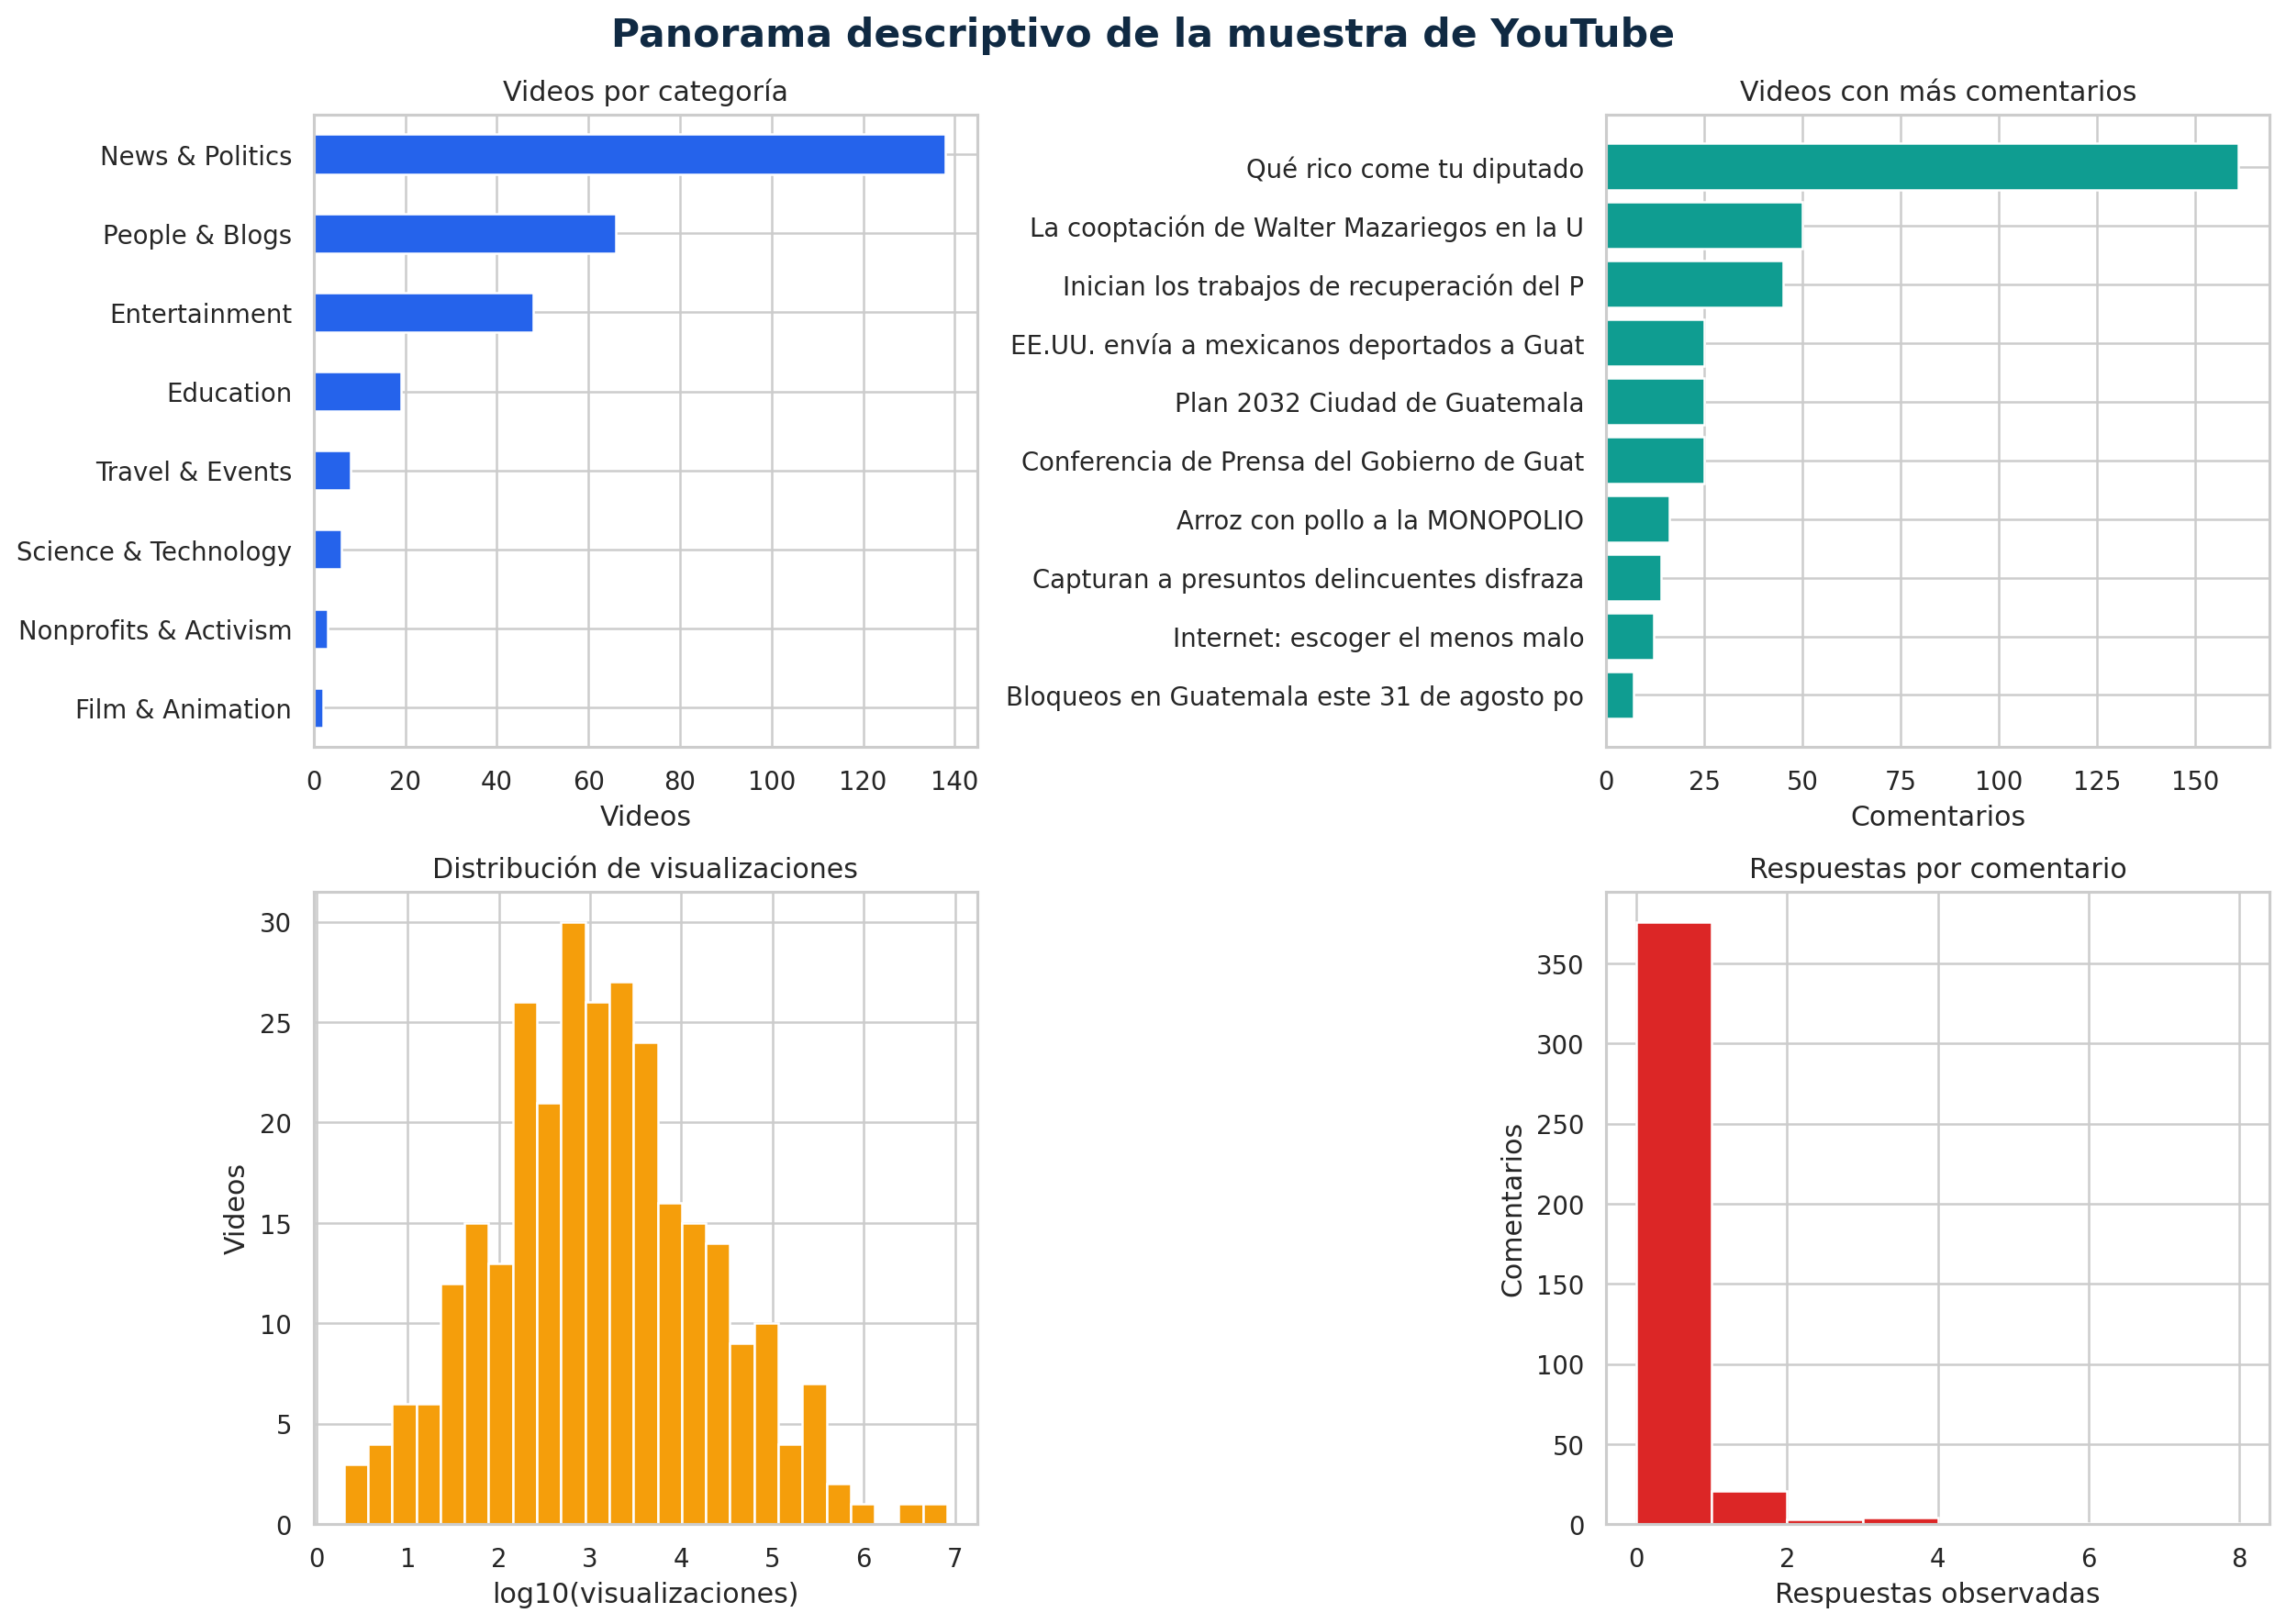

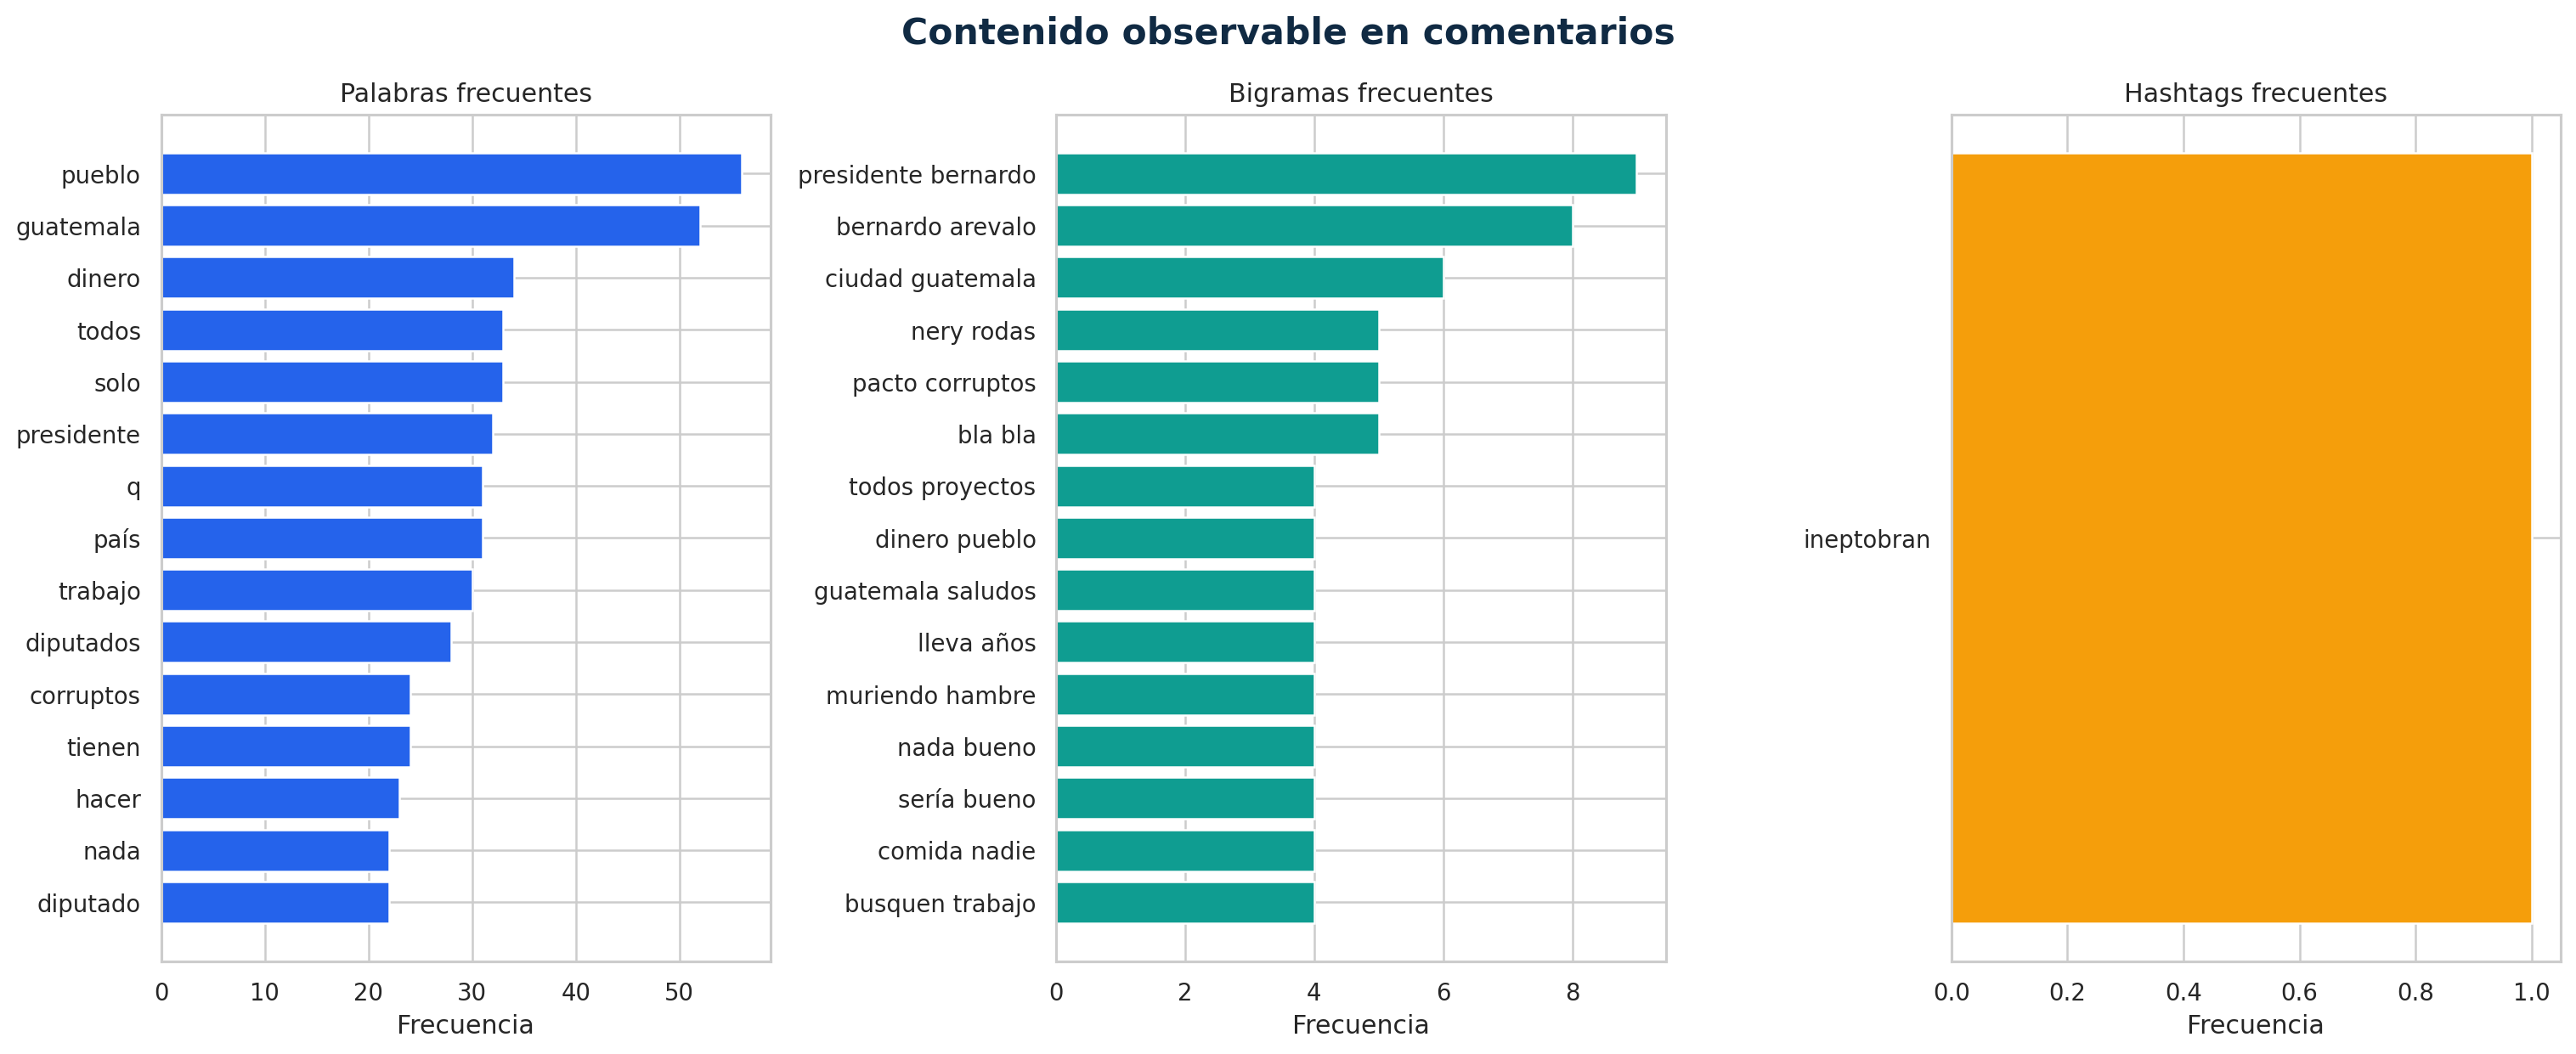

In [4]:
display(Image(filename=str(FIGURES / 'eda_panorama.png'), width=1000)); display(Image(filename=str(FIGURES / 'frecuencias_contenido.png'), width=1000))

<div class="insight"><b>Concentración.</b> El video con más participación fue <i>Qué rico come tu diputado</i>, con 161 comentarios. El canal líder fue Quorum con 256 comentarios. Los cinco videos principales concentran 75.4% de todos los comentarios.</div>

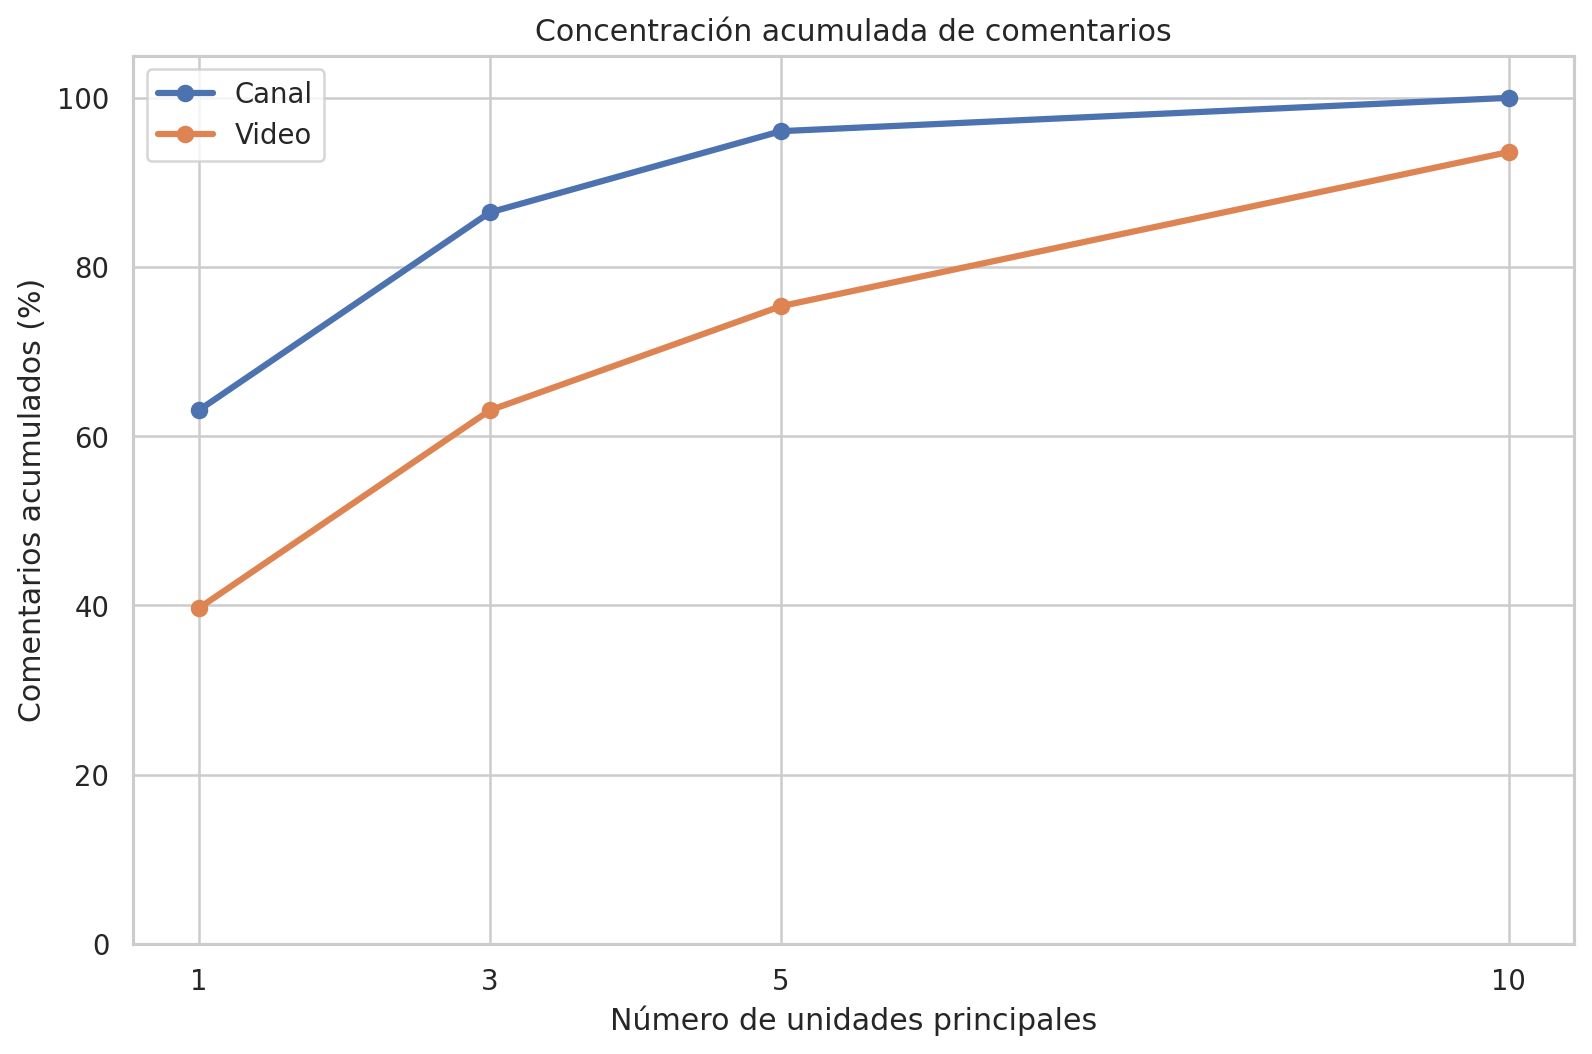

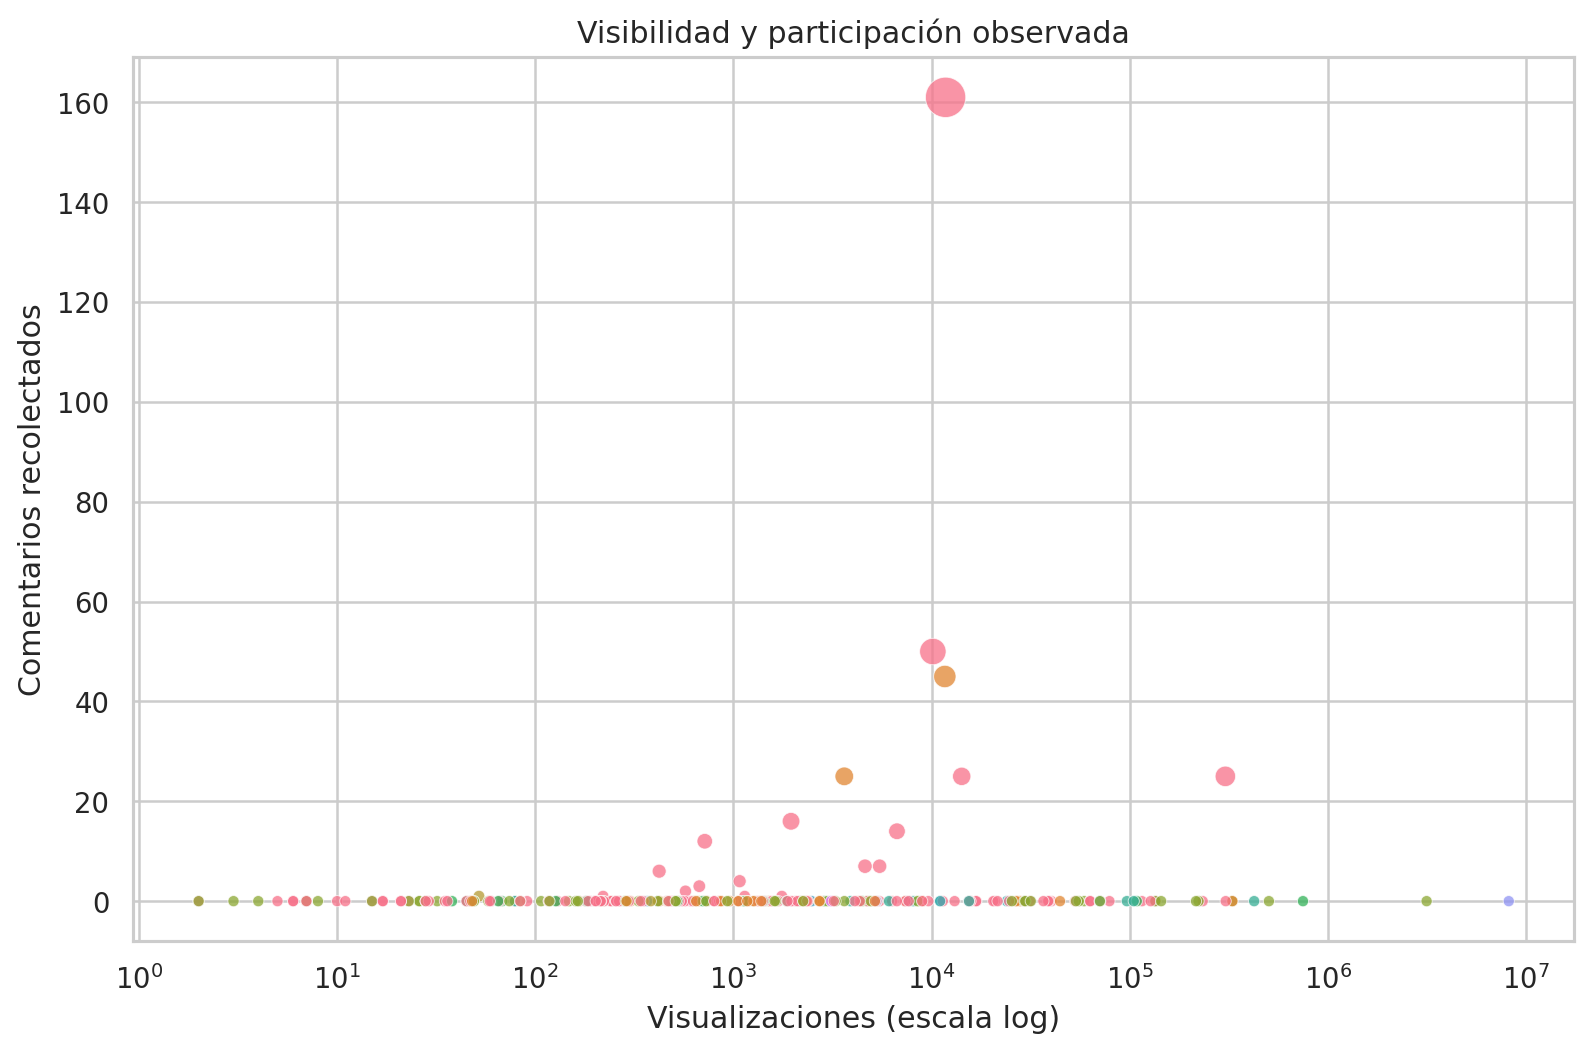

universo,n,spearman_rho,p_value
todos_los_videos,293,0.080323,0.170295
videos_con_comentarios,19,0.811497,0.000025


In [5]:
display(Image(filename=str(FIGURES / 'concentracion_participacion.png'), width=800)); display(Image(filename=str(FIGURES / 'visibilidad_vs_participacion.png'), width=800)); show_csv('asociacion_visibilidad_participacion.csv')

La correlación de Spearman entre visualizaciones y comentarios para todos los videos es **0.080**. Esto describe una asociación débil en la muestra; no prueba causalidad y está condicionada por la cobertura desigual de comentarios.

<div class="section"><h2>5 · Red bipartita autor–video</h2></div>
Una arista indica que un autor publicó al menos un comentario en un video; su peso es el número de comentarios de ese autor en ese video. No representa amistad, respuesta directa ni aprobación.

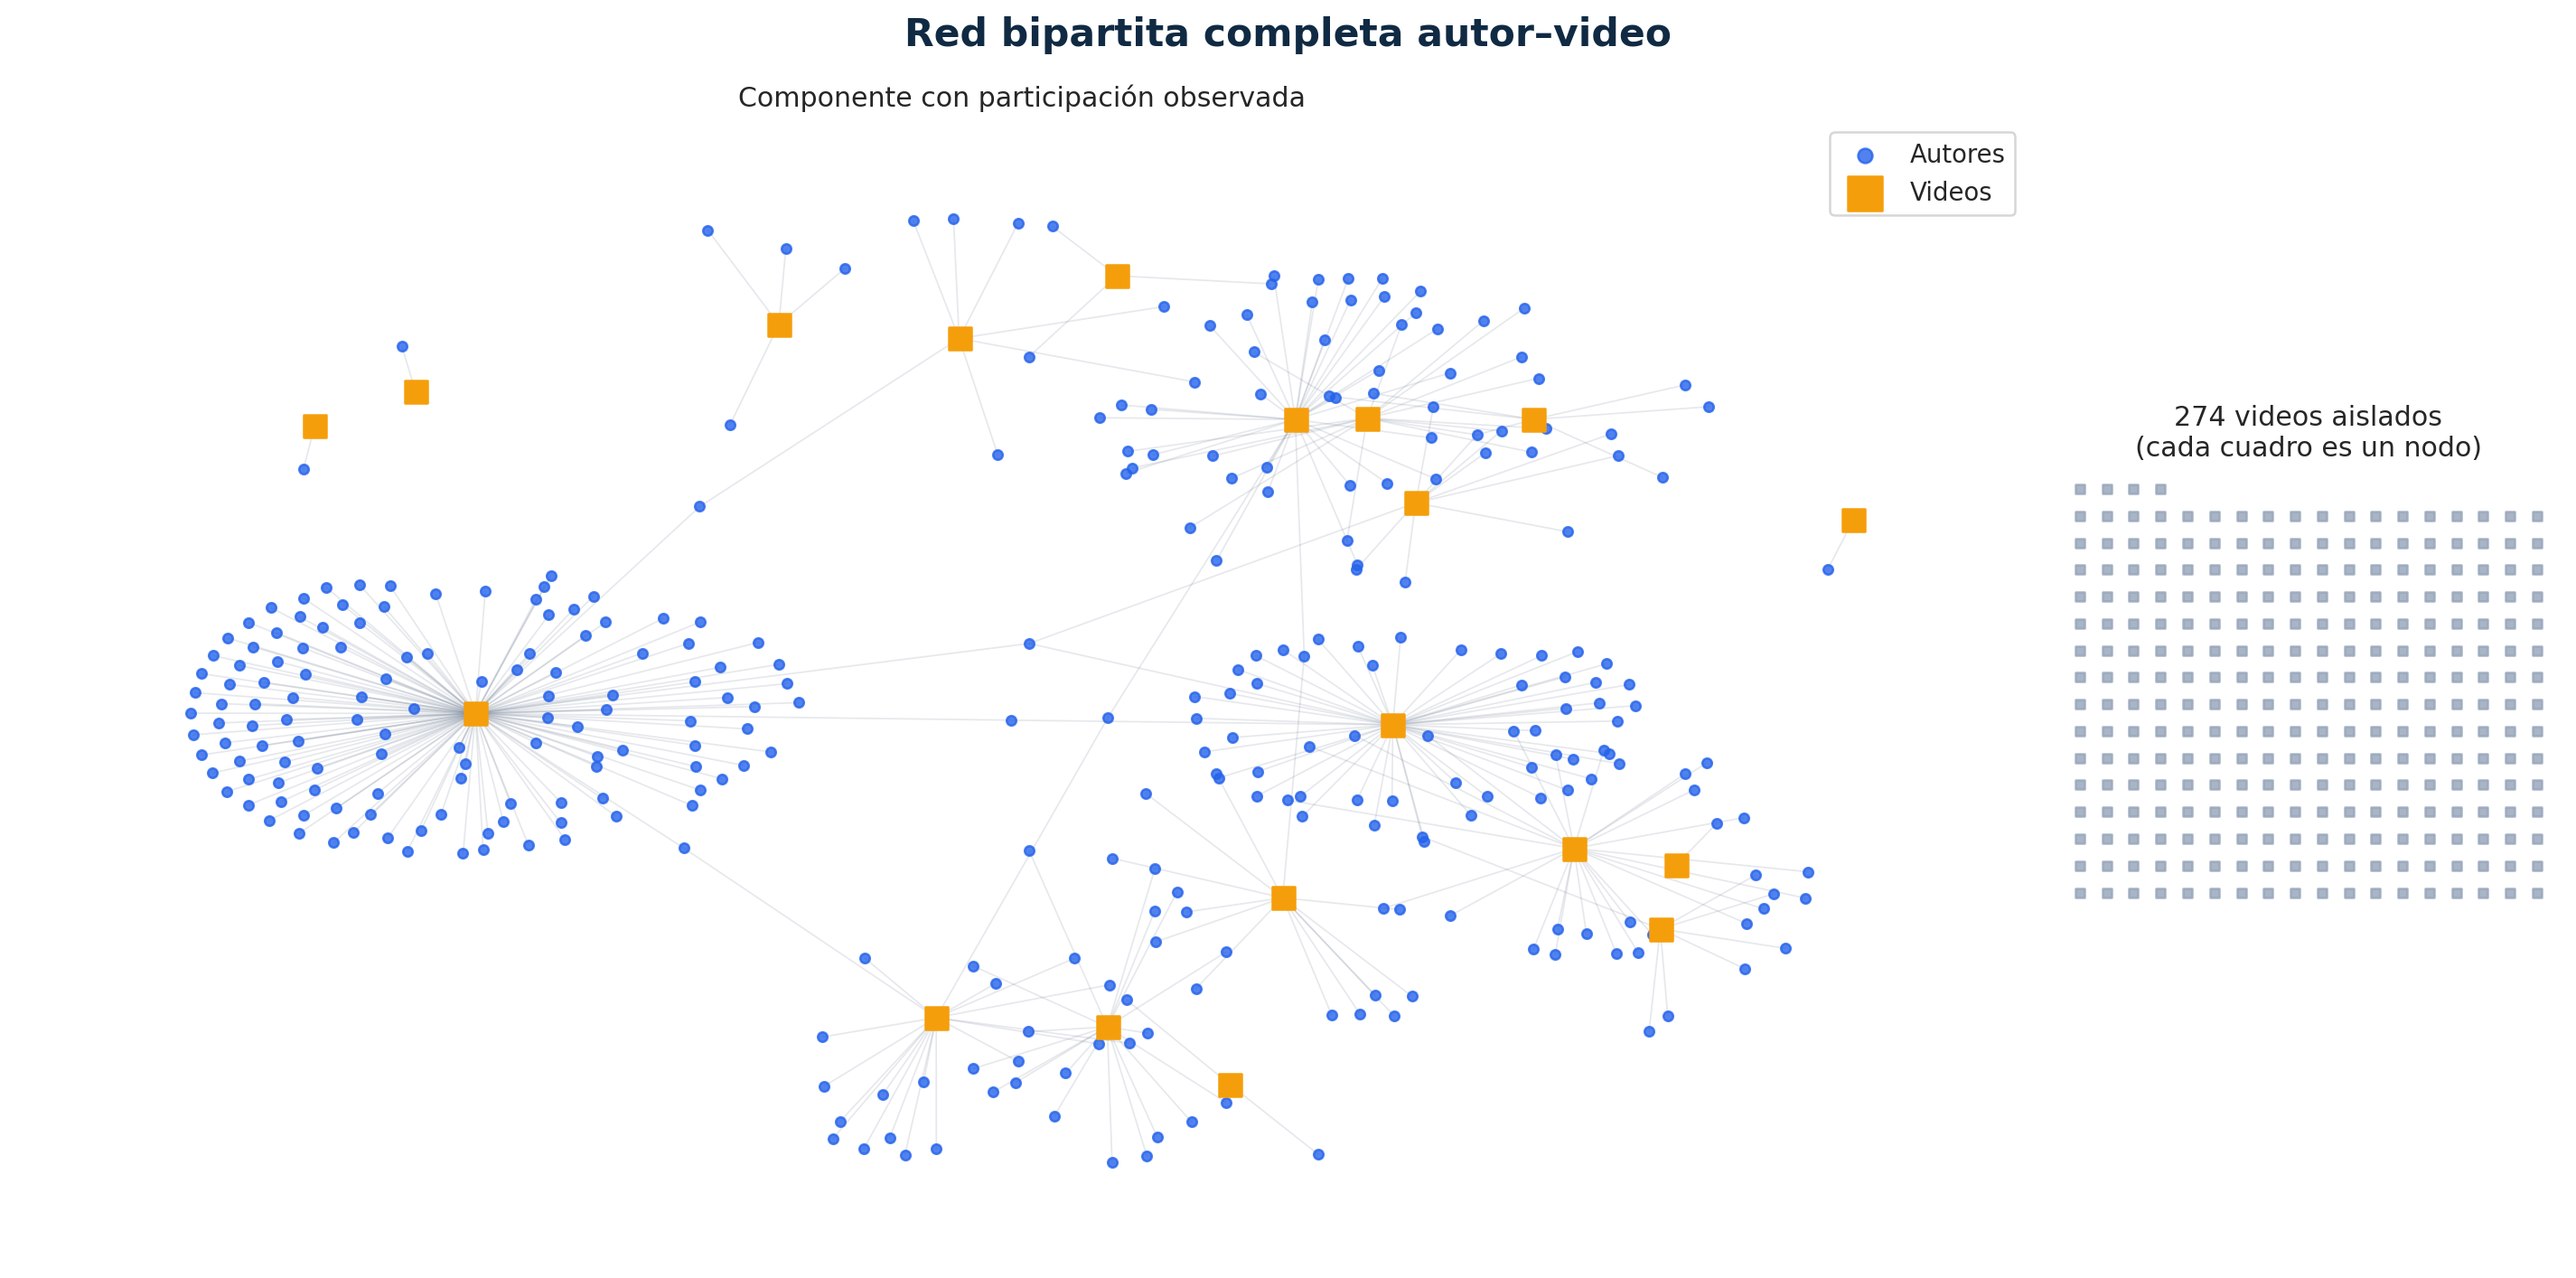

red,nodos,aristas,nodos_activos,nodos_aislados,densidad,grado_medio,grado_mediano,grado_maximo,componentes,componente_mayor,componente_mayor_pct,transitividad,clustering_medio,cohesion_nodos_lcc,cohesion_aristas_lcc,diametro_lcc
bipartita_autor_video,625,343,351,274,0.001759,1.097600,1.000000,128,284,286,45.760000,0.000000,0.000000,1,1,12
proyeccion_autores,332,10732,328,4,0.195319,64.650602,48.000000,183,10,276,83.132530,0.984025,0.486240,1,5,6
proyeccion_videos,293,11,10,283,0.000257,0.075085,0.000000,4,284,10,3.412969,0.315789,0.006092,1,1,5


In [6]:
display(Image(filename=str(FIGURES / 'red_bipartita_completa.png'), width=1100)); show_csv('metricas_redes.csv')

La red completa conserva videos sin comentarios: contiene **625 nodos**, **343 aristas** y **274 aislados**. La componente mayor reúne 45.8% de los nodos.

<div class="section"><h2>6 · Proyecciones y topología</h2></div>
En la proyección autor–autor el peso cuenta videos compartidos. En la proyección video–video cuenta autores compartidos. La primera aproxima copresencia de audiencias; la segunda, solapamiento entre contenidos.

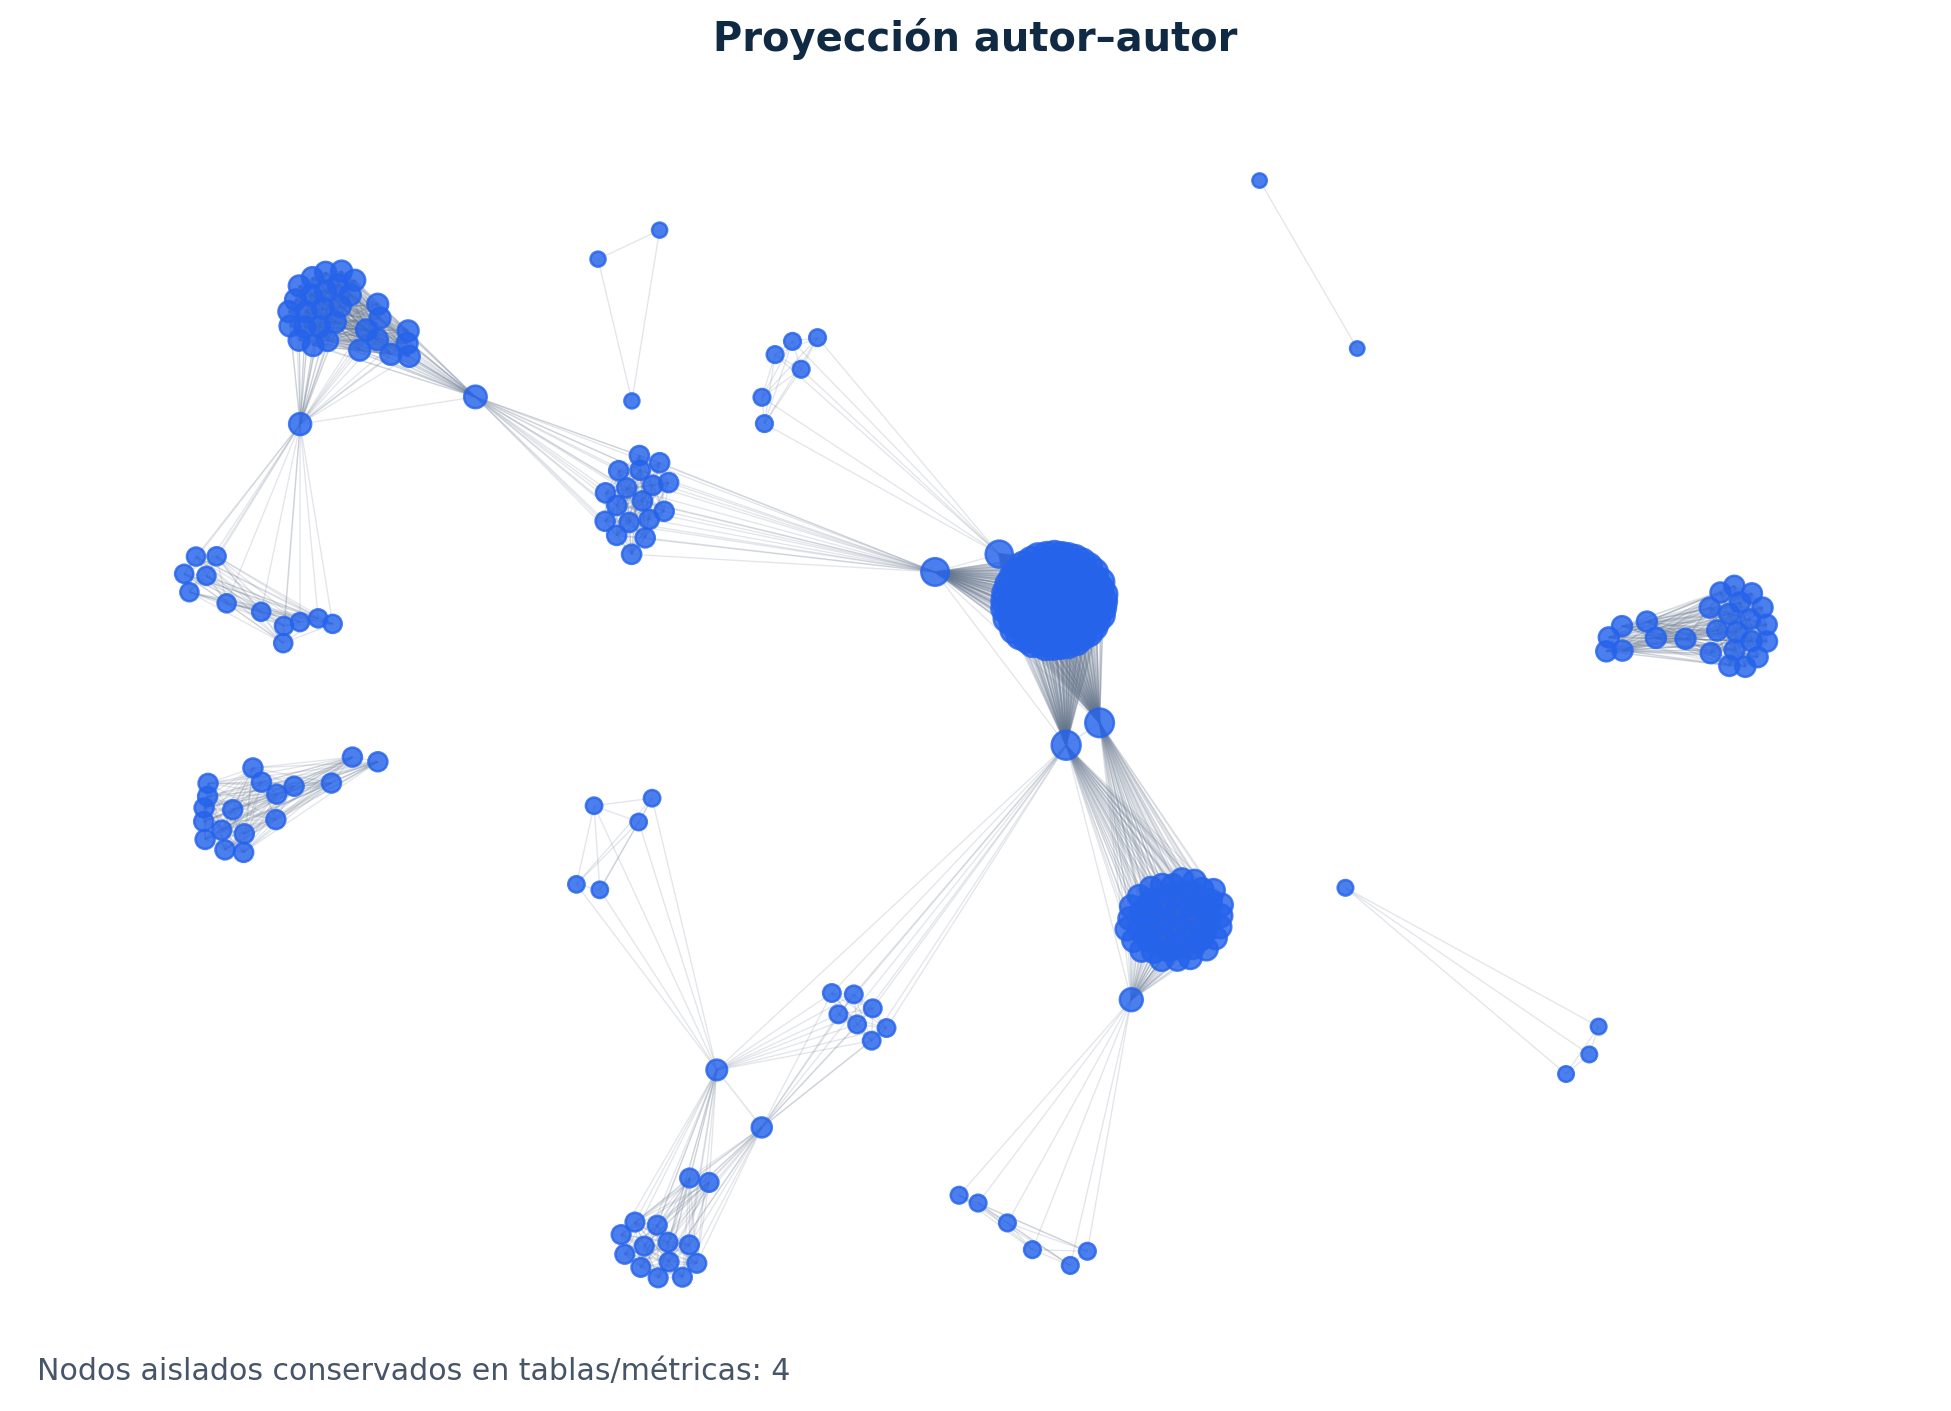

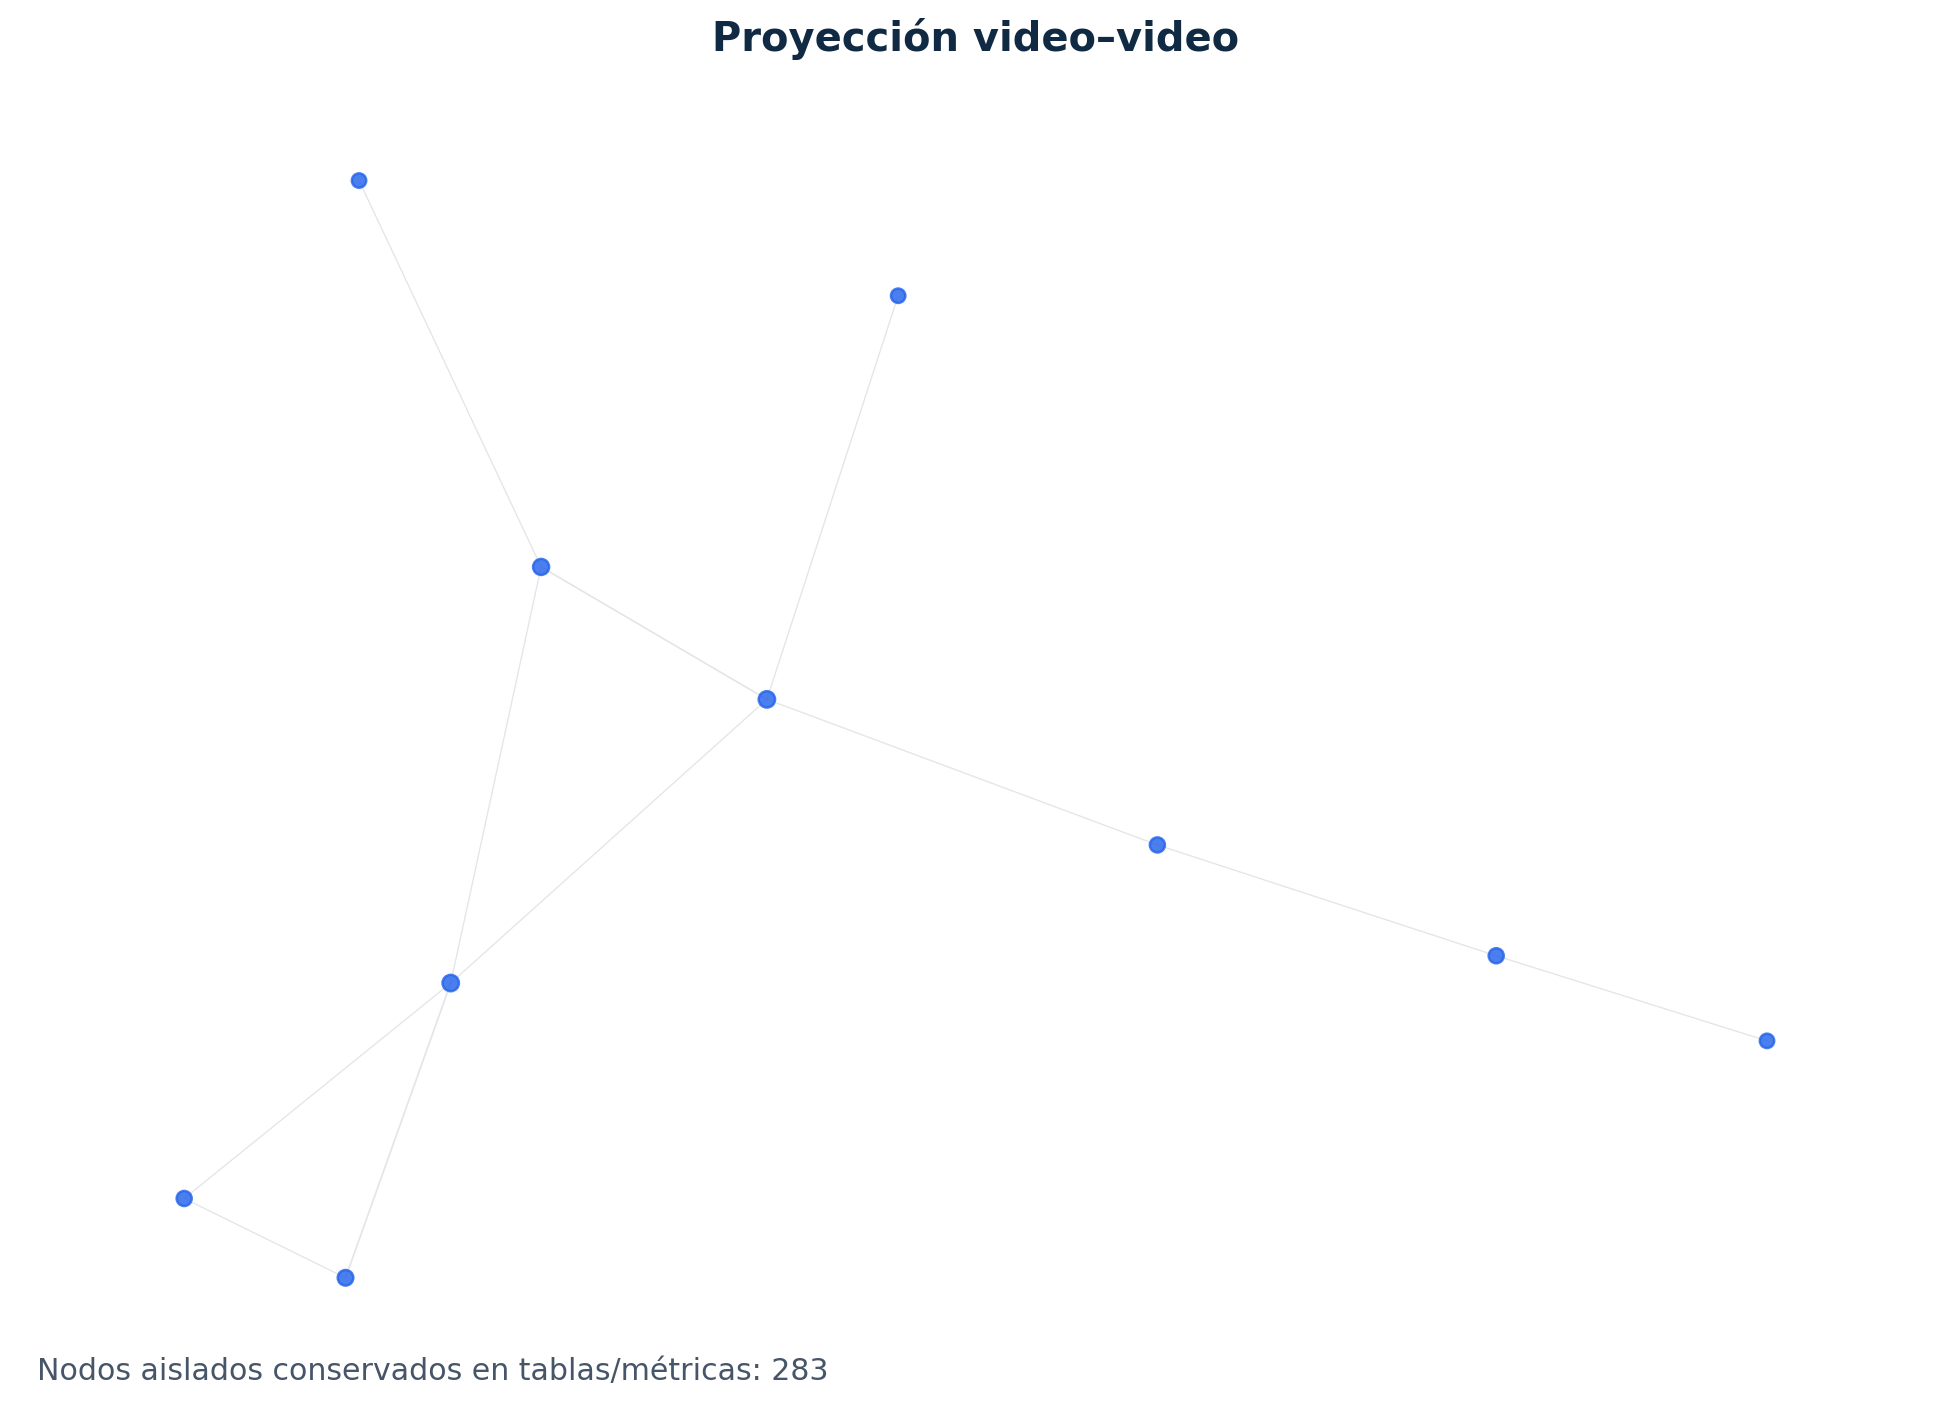

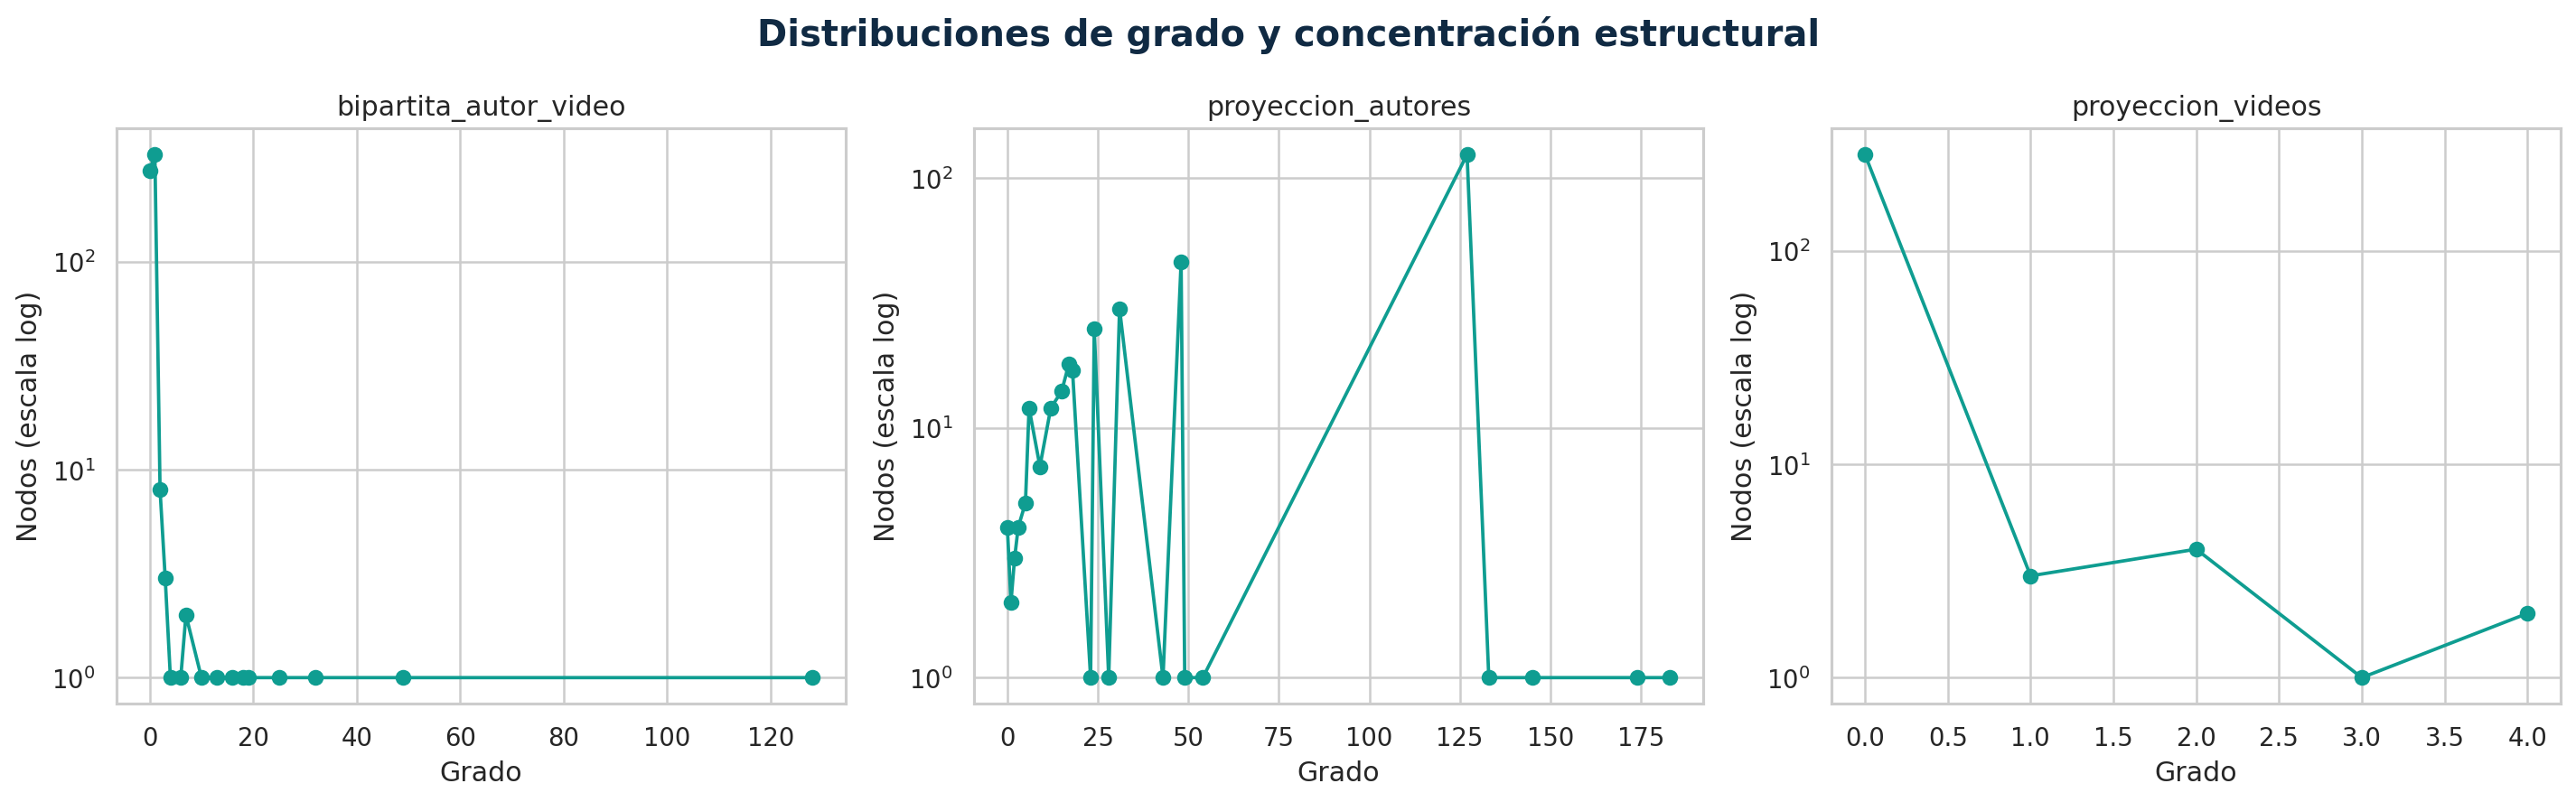

In [7]:
display(Image(filename=str(FIGURES / 'proyeccion_autores.png'), width=850)); display(Image(filename=str(FIGURES / 'proyeccion_videos.png'), width=850)); display(Image(filename=str(FIGURES / 'distribuciones_grado.png'), width=1000))

La proyección de autores tiene **10732 aristas**, transitividad **0.984** y una componente principal con 83.1% de los autores. La cohesión de la componente mayor se reporta mediante conectividad de nodos y aristas. La transitividad alta es esperable porque comentar un mismo video crea cliques; no implica relaciones sociales directas.

<div class="section"><h2>7 · Comunidades</h2></div>
Se aplicó Louvain ponderado a autores con al menos una coparticipación. Los aislados se conservaron en métricas y tablas, pero no aportan información a la optimización de modularidad.

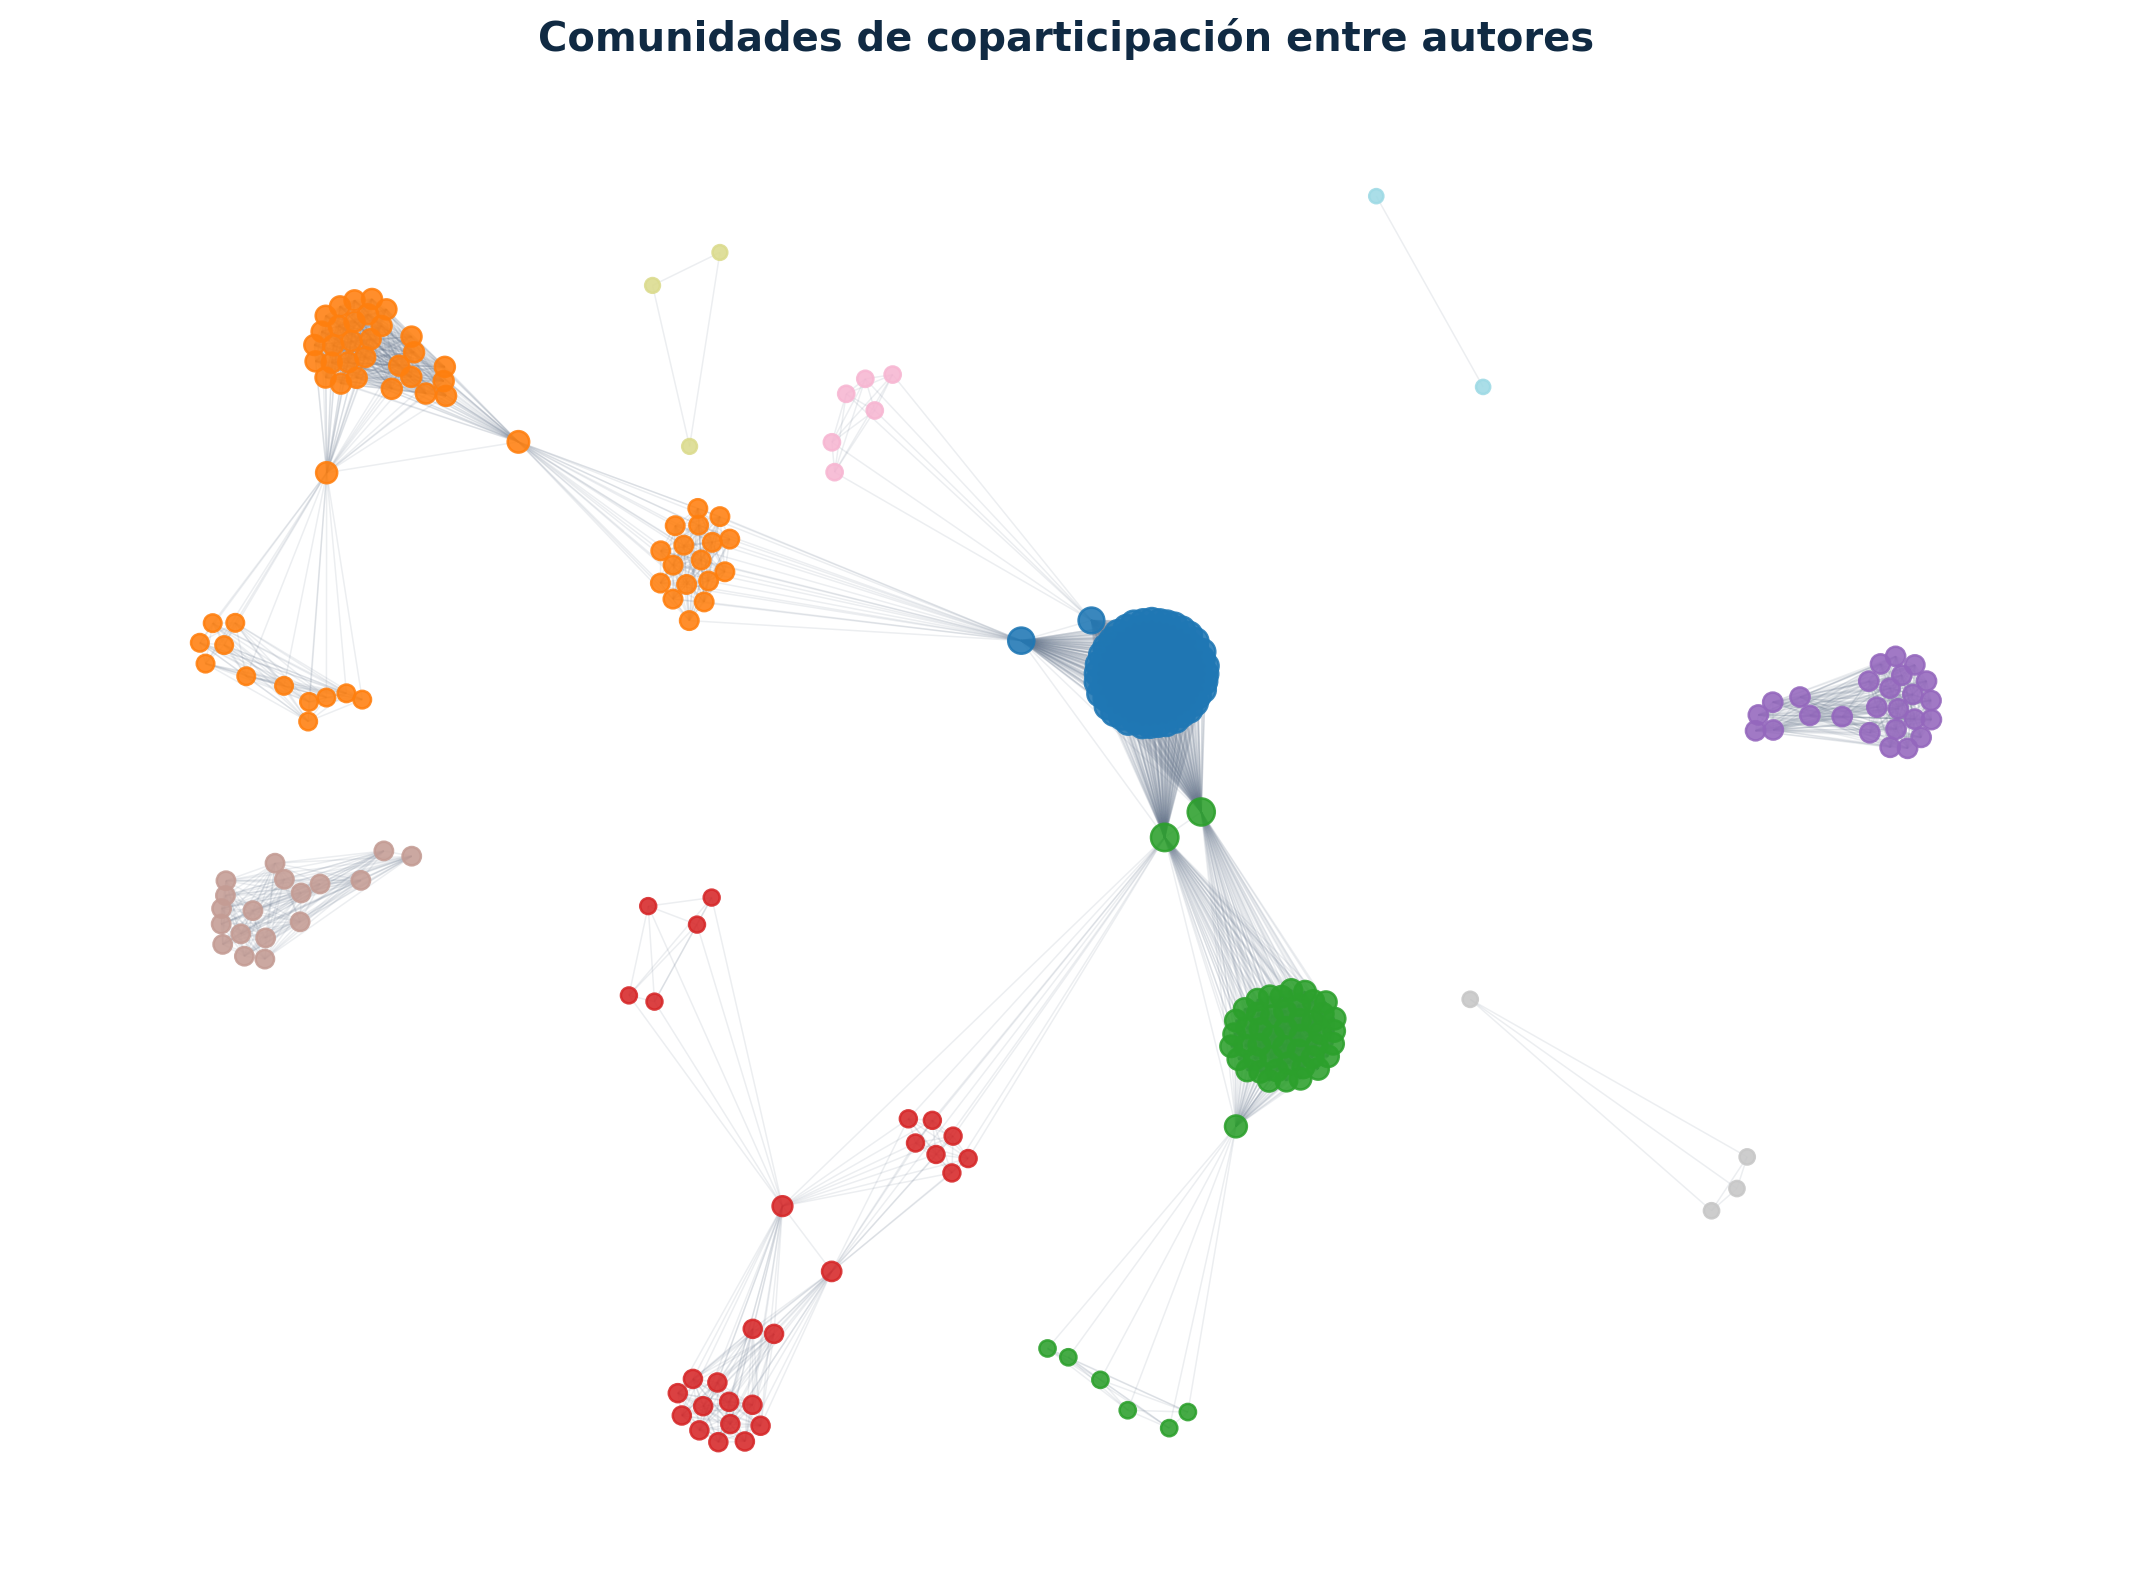

community,authors,comments,videos,channels,top_terms,top_videos,top_channels,top_categories,algoritmo,modularidad_global,sentimiento
1,126,161,3,3,"pueblo, dinero, diputados, trabajo, diputado, q, sueldo, tienen",Qué rico come tu diputado | Bloqueos en Guatemala este 31 de agosto por alza en combustibles afectan rutas principales | Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,Quorum | PrensaLibreOficial | Gobierno de la República de Guatemala,News & Politics | Entertainment,Louvain ponderado,0.394903,Pendiente para fase final con herramienta validada para español
2,61,83,3,2,"presidente, guatemala, país, años, arevalo, ni, bernardo, salvador",Inician los trabajos de recuperación del Puente Belice II. | Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt | Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,Gobierno de la República de Guatemala | Noti7,Entertainment | News & Politics,Louvain ponderado,0.394903,Pendiente para fase final con herramienta validada para español
3,55,60,4,2,"usac, corruptos, universidad, estudiantes, información, excelente, fuera, pueblo",La cooptación de Walter Mazariegos en la USAC | Capturan a ladrón que había quedado grabado mientras robaba en una parroquia de Retalhuleu | Qué rico come tu diputado,Quorum | TN23 Guatemala,News & Politics,Louvain ponderado,0.394903,Pendiente para fase final con herramienta validada para español
4,28,33,3,1,"excelente, empresas, solo, internet, ley, país, aquí, competencia",Arroz con pollo a la MONOPOLIO | Internet: escoger el menos malo | Caminar en una ciudad hecha para carros,Quorum,News & Politics,Louvain ponderado,0.394903,Pendiente para fase final con herramienta validada para español
5,25,25,1,1,"guatemala, ciudad, saludos, todos, viva, proyectos, tiempo, q",Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,News & Politics,Louvain ponderado,0.394903,Pendiente para fase final con herramienta validada para español
6,18,25,1,1,"you, usa, pais, otros, país, if, to, ver",EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo,Noticias Telemundo,News & Politics,Louvain ponderado,0.394903,Pendiente para fase final con herramienta validada para español
7,6,6,1,1,"asquerosos, gasolina, subira, guerra, países, guatemala, galón, país",Bloqueos en Guatemala este 31 de agosto por alza en combustibles afectan rutas principales,PrensaLibreOficial,News & Politics,Louvain ponderado,0.394903,Pendiente para fase final con herramienta validada para español
8,4,4,1,1,"iniciativa, juego, excelente, ve, deporte, dinamico, ni, entretenido","I’x K’at: el primer equipo guatemalteco de pelota maya, conformado únicamente por mujeres.",Quorum,News & Politics,Louvain ponderado,0.394903,Pendiente para fase final con herramienta validada para español
9,3,3,1,1,"guatemala, solo, cambia, dictadura, cada, años, vi, semilla",10 Preguntas a un año del Paro Nacional,Quorum,News & Politics,Louvain ponderado,0.394903,Pendiente para fase final con herramienta validada para español
10,2,2,1,1,"persona, encargada, ecosistema, ayude, problema, q, recuerdos, dejando","Noticiero en Directo 1 pm, 28 de Agosto de 2026",Noticiero Guatevisión 13 Hrs.,News & Politics,Louvain ponderado,0.394903,Pendiente para fase final con herramienta validada para español


In [8]:
display(Image(filename=str(FIGURES / 'comunidades_autores.png'), width=900)); show_csv('resumen_comunidades.csv', 10)

Se obtuvieron **10 comunidades** con modularidad **0.395**. Se caracterizan por autores, intensidad, videos, canales, categorías y vocabulario. El sentimiento se incorporará con una herramienta validada para español en la fase final.

<div class="section"><h2>8 · Preguntas y evidencia</h2></div>

In [9]:
show_csv('preguntas_obligatorias.csv', 10); show_csv('preguntas_adicionales.csv', 10)

pregunta,evidencia
¿Qué videos y canales concentran la mayor participación?,El video líder es 'Qué rico come tu diputado' (161 comentarios); el canal líder es 'Quorum' (256). El top 5 de videos reúne 75.4 %.
¿Existen audiencias compartidas?,La proyección video-video contiene 11 pares conectados por autores compartidos; la proyección autor-autor contiene 10732 pares.
¿Qué autores funcionan como puentes?,En el avance se observan 9 autores presentes en más de un video; su intermediación y efecto de remoción se reservan para la fase final.
¿Qué temas y sentimientos caracterizan comunidades?,"Se detectaron 10 comunidades con modularidad 0.395; sus términos, videos y categorías están tabulados. El sentimiento formal en español queda pendiente."
¿Coinciden visualizaciones y participación?,La asociación de Spearman en los 293 videos es rho=0.080; las visualizaciones y comentarios son cortes de cobertura distintos.
¿Qué limita las conclusiones?,Solo 19 de 293 videos tienen comentarios recolectados; la selección depende de consultas y los conteos son fotografías temporales.


pregunta,respuesta
¿Qué tan recurrente es la audiencia entre videos?,9 de 332 autores comentaron en más de un video.
¿Cuántos comentarios muestran conversación observable?,"30 de 406 comentarios tienen al menos una respuesta, pero no se conoce quién respondió."
¿Cómo se distribuyen los comentarios según la estrategia de búsqueda?,channel: 231; topic: 175.
¿Cuántos comentarios no muestran likes?,189 de 406 tienen conteo cero después de normalizar espacios en blanco.


<div class="section"><h2>9 · Alcance y siguiente fase</h2></div>
El avance cubre íntegramente los ejercicios 1–6 y la mayor parte del 7. La fase final añadirá sentimiento en español, centralidades justificadas, autores puente, videos articuladores, pruebas de remoción, caracterización completa de comunidades y conclusiones integradas.

In [10]:
show_csv('alcance_avance_75.csv', 12); print('Cobertura:', summary['scope_points'], '/', summary['scope_total'])

criterio,puntos_rubrica,puntos_cubiertos,estado
"Calidad, limpieza y preprocesamiento",18,18,completo
Análisis exploratorio,18,18,completo
Red bipartita autor-video,10,10,completo
Proyecciones,8,8,completo
Topología y fragmentación,12,12,completo
Comunidades,10,8,parcial: falta sentimiento
Nodos centrales y participantes puente,7,0,fase final
Contenido y sentimiento,5,0,fase final
"Interpretación, limitaciones y conclusiones finales",12,0,fase final; hay discusión preliminar


Cobertura: 74 / 100


### Referencias metodológicas
- Hagberg, A., Schult, D. y Swart, P. (2008). *Exploring network structure, dynamics, and function using NetworkX*.
- Blondel, V. et al. (2008). *Fast unfolding of communities in large networks*. Journal of Statistical Mechanics.
- Freeman, L. (1979). *Centrality in social networks: Conceptual clarification*. Social Networks.
<div class="footer">Laboratorio 6 · Grupo 1 · Data Science, Sección 10 · Avance reproducible</div>